In [1]:
import numpy as np
from oneargopy.OneArgo import Argo
from argopy import DataFetcher as ArgoDataFetcher
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
import cmocean
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import matplotlib.cm as cm # new package for the colorbar
import matplotlib.patches as mpatches
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from matplotlib.ticker import LogLocator, FormatStrFormatter
from matplotlib.colors import LogNorm
import gsw

# Cleaning data and calculating additional variables

In [2]:
pdf = pd.read_csv('/Users/lilah/Documents/IBIS_Project/Data/AAR_BGC_extended_region_alltime.csv')
# pdf = pd.read_csv('/Users/steviewalker/Documents/IBIS_Project/Data/AAR_BGC_extended_region_alltime.csv') #for stevie

/var/folders/sr/nn_fjjln6s33md98tyfc3rd40000gn/T/ipykernel_73463/518615070.py:1: DtypeWarning: Columns (6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  pdf = pd.read_csv('/Users/lilah/Documents/IBIS_Project/Data/AAR_BGC_extended_region_alltime.csv')


In [3]:
#convert to datetime
pdf['DATE'] = pd.to_datetime(pdf['DATE'],format = 'mixed')
pdf = pdf.dropna(subset=["DATE"]) #drop any cycles with no date or lat/lon (I found one cycle on a float that was causing these errors)

#fix lat lon values with '--' (replace with nan) (no longer needed since I found the problem float)
# pdf['LATITUDE'] = pd.to_numeric(pdf['LATITUDE'], errors='coerce')
# pdf['LONGITUDE'] = pd.to_numeric(pdf['LONGITUDE'], errors='coerce')


In [4]:
#create season columns
pdf["year"] = pdf["DATE"].dt.year.astype("Int64")
pdf["month"] = pdf["DATE"].dt.month.astype("Int64")

def assign_season(row):
    m = int(row["month"])
    y = int(row["year"])
    if m >= 9:
        return f"{y}-{y+1}"
    elif m <= 4:
        return f"{y-1}-{y}"
    else:
        return f"{y}"

pdf["season"] = pdf.apply(assign_season, axis=1)

In [5]:
# define function for calculating SA, CT, potential dens, in-situ dens
def calc_phys_vars(df):
        
    # Columns needed
    cols = ['PSAL_ADJUSTED','TEMP_ADJUSTED' ,'PRES_ADJUSTED', 'LATITUDE', 'LONGITUDE']
    
    # only do calculation on good qc T and S data - create nan values where not good data
    qc_flags = [1, 2, 8]
    mask_qc = df['PSAL_ADJUSTED_QC'].isin(qc_flags) & df['TEMP_ADJUSTED_QC'].isin(qc_flags)
    df['PSAL_ADJUSTED'] = df['PSAL_ADJUSTED'].where(mask_qc)
    df['TEMP_ADJUSTED'] = df['TEMP_ADJUSTED'].where(mask_qc)    
    
    # mask valid (non-null) rows
    mask = df[cols].notnull().all(axis=1)
    
    # initialize outputs as NaN
    SA = np.full(len(df), np.nan)
    CT = np.full(len(df), np.nan)
    rho = np.full(len(df), np.nan)
    sigma0 = np.full(len(df), np.nan)
    
    # extract numeric arrays for valid rows
    SP = df.loc[mask, 'PSAL_ADJUSTED'].astype(float).to_numpy()
    PT = df.loc[mask, 'TEMP_ADJUSTED'].astype(float).to_numpy()
    pres = df.loc[mask, 'PRES_ADJUSTED'].astype(float).to_numpy()
    LAT = df.loc[mask, 'LATITUDE'].astype(float).to_numpy()
    LON = df.loc[mask, 'LONGITUDE'].astype(float).to_numpy()
    
    # calculate variables using gsw
    SA_valid = gsw.SA_from_SP(SP=SP, p=pres, lon=LON, lat=LAT)
    CT_valid = gsw.CT_from_t(SA=SA_valid, t=PT, p=pres)
    rho_valid = gsw.rho(SA=SA_valid, CT=CT_valid, p=pres)
    sigma0_valid = gsw.sigma0(SA=SA_valid, CT=CT_valid)
    
    # store back into full-length arrays
    SA[mask] = SA_valid
    CT[mask] = CT_valid
    rho[mask] = rho_valid
    sigma0[mask] = sigma0_valid
    
    # sdd results to the dataframe
    df = df.copy()
    df['SA'] = SA
    df['CT'] = CT
    df['rho'] = rho
    df['sigma0'] = sigma0
    
    return df

pdf = calc_phys_vars(pdf)

In [8]:
#function for calculating MLD
#0.03 kg/m3 threshold

def calc_mlp_density(df_profile, delta_sigma=0.03):
    #calc MLD for a single profile using density threshold
    df_profile = df_profile.sort_values('PRES_ADJUSTED')

    # get SA, CT, and potential density values
    SA = df_profile['SA']
    CT = df_profile['CT']
    sigma0 = df_profile['sigma0']

    sigma_surface = sigma0.iloc[0]
    d_sigma = sigma0 - sigma_surface

    # find first depth where density difference exceeds threshold
    idx = np.argmax(d_sigma > delta_sigma)
    if d_sigma.iloc[idx] <= delta_sigma:
        return np.nan  # no threshold reached
    return df_profile['PRES_ADJUSTED'].iloc[idx]

mld = (pdf.groupby(['WMOID', 'CYCLE_NUMBER']).apply(calc_mlp_density).reset_index(name='MLP'))
pdf = pdf.merge(mld, on=['WMOID', 'CYCLE_NUMBER'], how='left')


/var/folders/sr/nn_fjjln6s33md98tyfc3rd40000gn/T/ipykernel_73463/4100982497.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mld = (pdf.groupby(['WMOID', 'CYCLE_NUMBER']).apply(calc_mlp_density).reset_index(name='MLP'))


In [31]:
#function for QC-ing on a column by column basis
def basic_qc(df,varname):
    # replace bad qc values for each column with nan
    df_out = df.copy()
    qc_flags = [1, 2, 8]
    mask_qc = df_out[f'{varname}_ADJUSTED_QC'].isin(qc_flags)
    df_out[f'{varname}_ADJUSTED'] = df_out[f'{varname}_ADJUSTED'].where(mask_qc)
    return df_out

#or subset all columns where QC flags are true
def subset_qc(df,varname):
    qc_flags = [1,2,8]
    df = df[df[f'{varname}_ADJUSTED_QC'].isin(qc_flags)]
    return df

pdf_clean = basic_qc(pdf, 'CHLA')

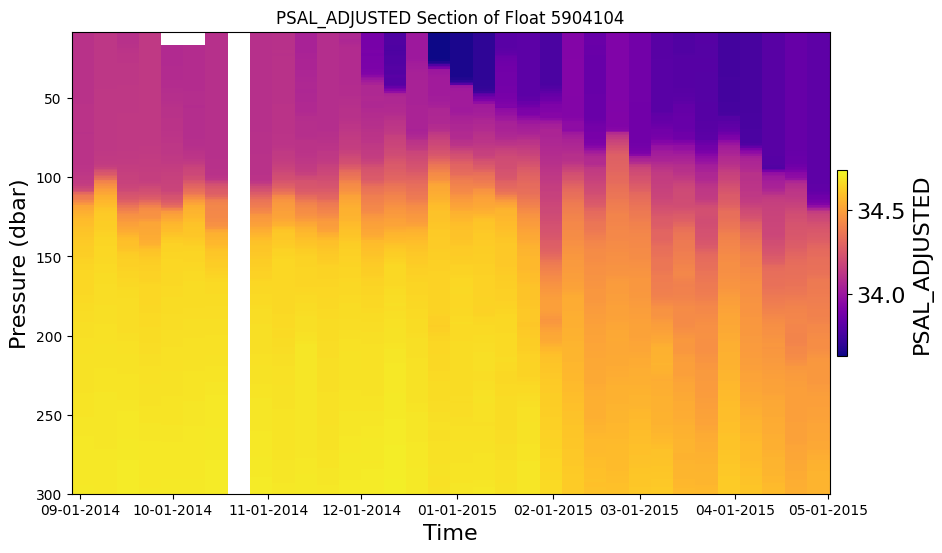

In [78]:
#these will be some of the inputs to your function
# variable = 'CHLA_ADJUSTED'
# xlab = 'time'
# ylab= 'depth'
# label_size = 12
# title_size = 14
# df_ts = pdf #switch between qc'ed and non-qc'ed data here
# season = '2014-2015'
# WMOID = 5904104


def section(variable, xlab, ylab, label_size, title_size, df_ts, season, WMOID):

    df_ts = df_ts[df_ts['season'].isin([season])]
    float_data = df_ts[df_ts['WMOID'].isin([WMOID])]
    
    # regridding data (from oneargopy code) -----------
    
    time_values = pd.to_datetime(float_data['DATE']).values
    pres_values = float_data['PRES'].values
    param_values = float_data[variable].values
    # Remove NaN values
    valid_indices = ~np.isnan(time_values) & ~np.isnan(pres_values) & ~np.isnan(param_values)
    time_values = time_values[valid_indices]
    pres_values = pres_values[valid_indices]
    param_values = param_values[valid_indices]
    # Convert time_values to float because it makes gridding data easier
    time_values_num = mdates.date2num(time_values)
    # Unique values for creating grids
    unique_times_num = np.unique(time_values_num)
    # Create a pressure axis with regular intervals, covering all existing values
    intp_pres = np.arange(np.ceil(min(pres_values)), np.floor(max(pres_values)))
    # Create grid for interpolation
    time_grid, pres_grid = np.meshgrid(unique_times_num, intp_pres)
    # Set param_gridded to NaN array with the same shape as the grid
    param_gridded = np.full(time_grid.shape, np.nan)
    # Create a DataFrame
    df = pd.DataFrame({
        'time': time_values_num,
        'pressure': pres_values,
        'param': param_values
    })
    # Pivot the DataFrame to create a grid
    param_gridded_df = df.pivot_table(
        index='pressure',
        columns='time',
        values='param',
        aggfunc='first'
    )
    # Create a new index that contains original and regularly spaced pressure values
    all_pres = np.sort(np.unique(np.concatenate([pres_values, intp_pres])))
    # Reindex the DataFrame to the combined depth axis
    param_gridded_df = param_gridded_df.reindex(index=all_pres, columns=unique_times_num)
    # Perform linear interpolation to the new depth axis without extrapolation
    param_gridded_df.interpolate(method='linear', limit_area='inside', axis=0, inplace=True)
    # Extract the values to the regularly spaced depth values
    param_gridded_df = param_gridded_df.reindex(index=intp_pres, columns=unique_times_num)
    # Assigning data to variable to graph
    param_gridded = param_gridded_df.values
    
    # plotting data -----------------
    
    fig = plt.figure(figsize=(10, 6))
    
    ax = fig.add_subplot(111)
    plot = ax.pcolormesh(time_grid, pres_grid, param_gridded, shading='auto', cmap='plasma')
    ax.set_ylim([0, 300])
    ax.invert_yaxis()
    # Add a colorbar to show the scale of the variable
    cbar = fig.colorbar(plot, fraction=0.012, pad=0.01)
    cbar.ax.tick_params(labelsize=16)
    cbar.set_label(f'{variable}', size=16)
    # X Axis
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d-%Y'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    # Titles
    ax.set_ylim(300, 8)
    ax.set_xlabel('Time', fontsize=16)
    ax.set_ylabel('Pressure (dbar)', fontsize=16)
    ax.set_title(f'{variable} Section of Float {WMOID}')

    
    # add save path
    # fig.savefig(f'/Users/lilah/Documents/IBIS_Project/Figures/float_trajectories_{season}.png') #uncomment for lilah
    # fig.savefig(f'/Users/steviewalker/Documents/IBIS_Project/Figures/float_trajectories_{season}.png') #uncomment for stevie

section(variable='PSAL_ADJUSTED', xlab='time', ylab='depth', label_size=16, title_size=18, df_ts=pdf, season='2014-2015', WMOID=5904104)